In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("adult.csv")

In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df=df.replace("?",pd.NA)
df=df.dropna()

In [8]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [9]:
df['income']=df['income'].apply(lambda x:1 if x.strip()==">50K" else 0)

In [10]:
df['income'].value_counts()

income
0    22654
1     7508
Name: count, dtype: int64

In [11]:
x=df.drop("income",axis=1)
y=df['income']

In [12]:
categotical_features=x.select_dtypes(include=['object']).columns.tolist()
categotical_features

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weight=compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train
)
weight

array([0.66577452, 2.00807257])

In [15]:
from catboost import CatBoostClassifier

model=CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=15,
    eval_metric="F1",
    class_weights=weight,
    early_stopping_rounds=100,
    verbose=100
)

model.fit(x_train,y_train,cat_features=categotical_features,
          eval_set=(x_test,y_test))


0:	learn: 0.8149575	test: 0.8103539	best: 0.8103539 (0)	total: 363ms	remaining: 6m 2s
100:	learn: 0.8515312	test: 0.8405289	best: 0.8405289 (100)	total: 12.6s	remaining: 1m 52s
200:	learn: 0.8572163	test: 0.8437308	best: 0.8438222 (196)	total: 23.5s	remaining: 1m 33s
300:	learn: 0.8629080	test: 0.8441525	best: 0.8446459 (271)	total: 35s	remaining: 1m 21s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8446458961
bestIteration = 271

Shrink model to first 272 iterations.


CatBoostClassifier(class_weights=array([0.66577452, 2.00807257]), depth=6, early_stopping_rounds=100, eval_metric='F1', iterations=1000, l2_leaf_reg=15, learning_rate=0.1, verbose=100)

In [16]:
from sklearn.metrics import accuracy_score,classification_report
y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)

print(acc)
print(report)

0.8324216807558429
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      4533
           1       0.62      0.86      0.72      1500

    accuracy                           0.83      6033
   macro avg       0.78      0.84      0.80      6033
weighted avg       0.86      0.83      0.84      6033



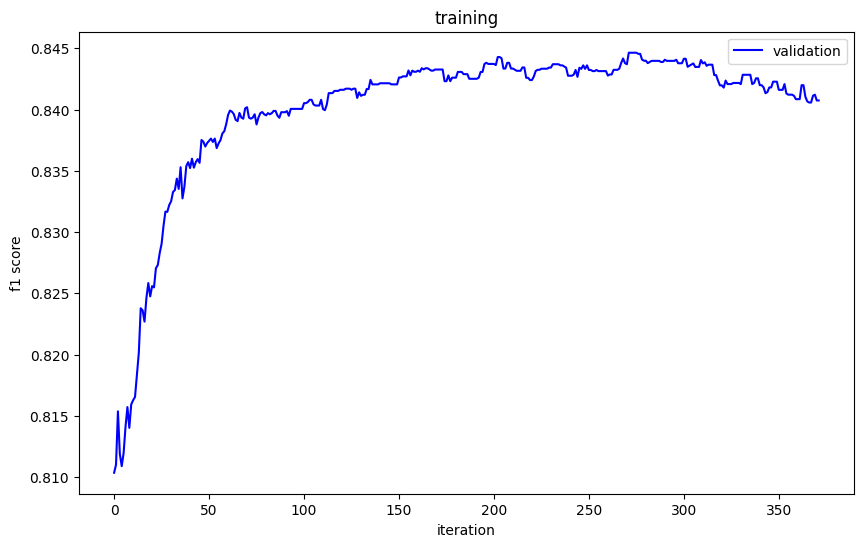

In [17]:
import matplotlib.pyplot as plt

train_metrics=model.get_evals_result()
train_f1=train_metrics['validation']['F1']

plt.figure(figsize=(10,6))
plt.plot(train_f1,label="validation",color='blue')
plt.title("training")
plt.xlabel("iteration")
plt.ylabel("f1 score")
plt.legend()
plt.show()